<a href="https://colab.research.google.com/github/springboardmentor443m-coder/AI-Skin-Intelligence-Personalized-Skincare-Planner/blob/Subhransu-Sekhar/Image_Skin_type_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1.1: Mount Google Drive
If you upload your dataset zip file to Google Drive, use this cell to access it. If you upload directly to Colab's temporary storage, you can skip this.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 1.2: Initialize Generators for Skin Type
We will start by loading the data for the **Skin Type** model first. Change `DATASET_BASE_PATH` to the location where you extracted your folders.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. DEFINE THE CORRECTED HELPER FUNCTION
def build_generators(base_path, task_folder_name):
    task_path = os.path.join(base_path, task_folder_name)

    # Training Generator: Includes augmentations, raw pixel values [0-255] for EfficientNet
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Validation & Test Generator: STRICTLY NO AUGMENTATION
    test_datagen = ImageDataGenerator()

    # Flow from directories
    train_gen = train_datagen.flow_from_directory(
        os.path.join(task_path, 'Train'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical'
    )

    val_gen = test_datagen.flow_from_directory(
        os.path.join(task_path, 'Validation'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_gen = test_datagen.flow_from_directory(
        os.path.join(task_path, 'Test'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, val_gen, test_gen

# 2. SET THE FINAL VERIFIED PATH
DATASET_BASE_PATH = '/content/drive/MyDrive/Data sets/'

# 3. LOAD DATA FOR SKIN TYPE
try:
    type_train_gen, type_val_gen, type_test_gen = build_generators(DATASET_BASE_PATH, 'Skin type')
    print(f"\nSuccess! Skin Type Classes: {list(type_train_gen.class_indices.keys())}")
except Exception as e:
    print(f"\nError loading data: {e}")

Found 7086 images belonging to 4 classes.
Found 1254 images belonging to 4 classes.
Found 723 images belonging to 4 classes.

Success! Skin Type Classes: ['Combination', 'Dry', 'Normal', 'Oily']


### Step 1.3: Data Exploration & Visualization
Let's verify the class distribution and look at some samples to ensure the data loaded correctly.

In [ ]:
import pandas as pd

def show_dataset_stats(base_path, task):
    stats = []
    task_path = os.path.join(base_path, task)
    for split in ['Train', 'Validation', 'Test']:
        split_path = os.path.join(task_path, split)
        classes = os.listdir(split_path)
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                count = len(os.listdir(cls_path))
                stats.append({'Split': split, 'Class': cls, 'Images': count})

    df_stats = pd.DataFrame(stats)
    pivot_stats = df_stats.pivot(index='Class', columns='Split', values='Images').fillna(0).astype(int)
    display(pivot_stats)

print("Dataset Distribution for Skin Type:")
show_dataset_stats(DATASET_BASE_PATH, 'Skin type')


Dataset Distribution for Skin Type:


Split,Test,Train,Validation
Class,,,
Combination,75,612,108
Dry,193,1859,373
Normal,264,2444,419
Oily,191,2171,354



--- Samples from Train Set ---


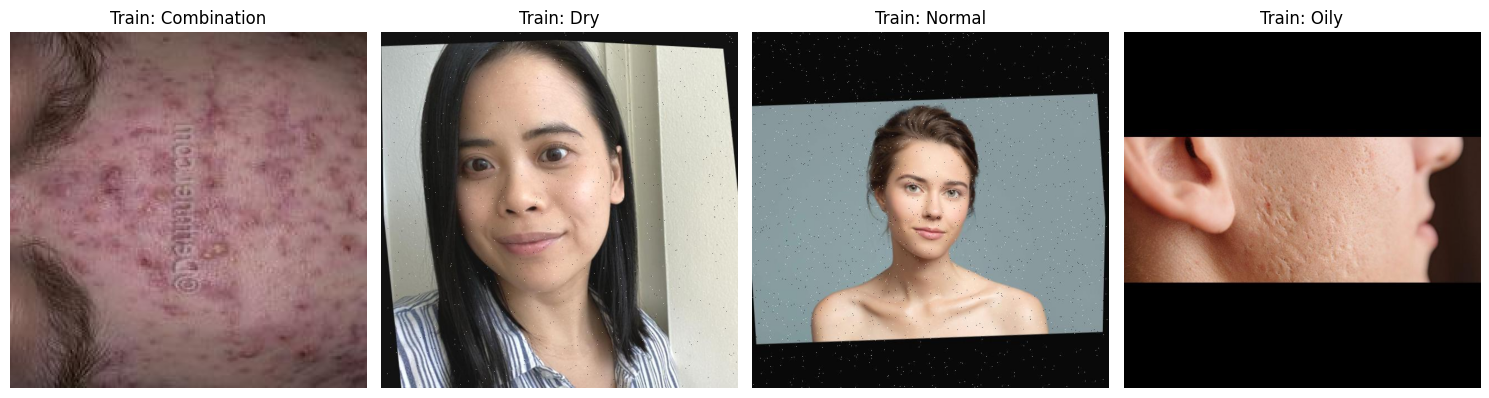


--- Samples from Validation Set ---


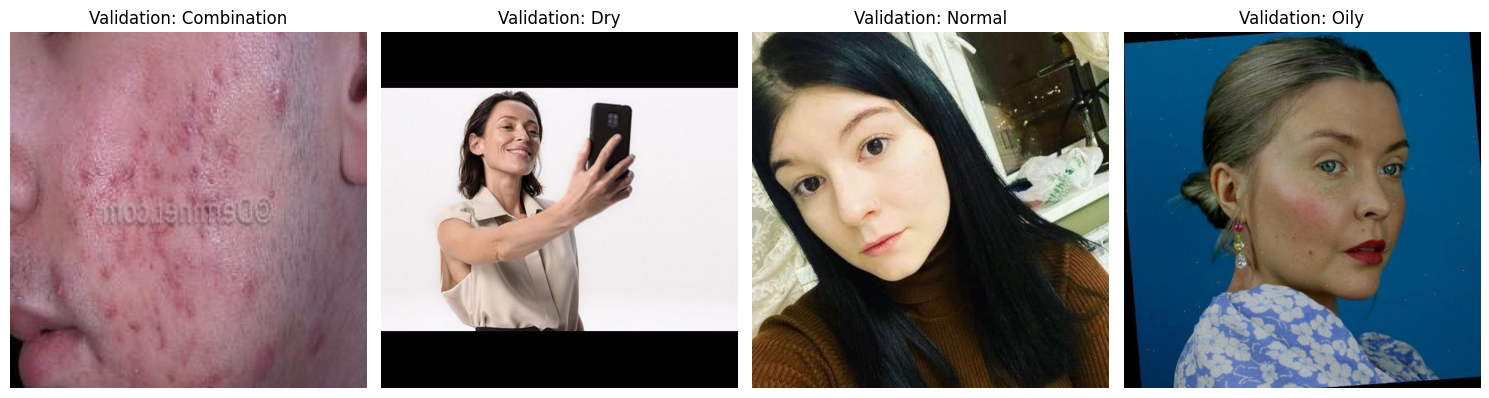


--- Samples from Test Set ---


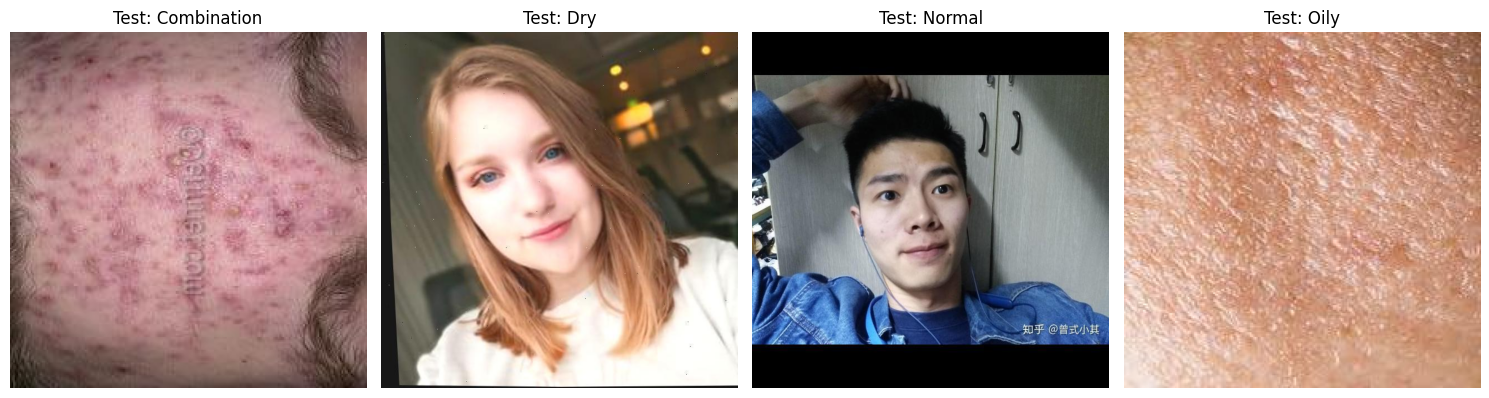

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

def display_all_samples(base_path, task):
    task_path = os.path.join(base_path, task)
    splits = ['Train', 'Validation', 'Test']

    for split in splits:
        split_path = os.path.join(task_path, split)
        if not os.path.exists(split_path):
            print(f"Path not found: {split_path}")
            continue

        # Get directories (classes)
        classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])

        if not classes:
            continue

        print(f"\n--- Samples from {split} Set ---")
        plt.figure(figsize=(15, 4))

        for i, cls in enumerate(classes):
            cls_path = os.path.join(split_path, cls)
            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            if images:
                img_name = random.choice(images)
                img_path = os.path.join(cls_path, img_name)

                img = mpimg.imread(img_path)
                plt.subplot(1, len(classes), i + 1)
                plt.imshow(img)
                plt.title(f"{split}: {cls}")
                plt.axis('off')
            else:
                print(f"No images found for class {cls} in {split} split.")

        plt.tight_layout()
        plt.show()

# Execute the function for 'Skin type'
display_all_samples(DATASET_BASE_PATH, 'Skin type')

### Step 2: Build and Train the Skin Type Model (EfficientNetB0)
We use EfficientNetB0 for macro-level skin type detection because it is highly efficient and lightweight for mobile/web backends.Skin Type Classification Model

In [ ]:
# for increasing accurcay
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0
import os
import json

# =====================================================================
# 1. EXPLICIT DIRECTORY SETUP
# =====================================================================
# We now point STRICTLY to the Skin type folder.
# The model has zero awareness that the 'Skin concerns' folder even exists.
SKIN_TYPE_DIR = '/content/drive/MyDrive/Data sets/Skin type'

def build_skin_type_generators(target_dir):
    # Training Generator: Includes augmentations, raw pixel values (0-255)
    train_datagen = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
        horizontal_flip=True, fill_mode='nearest'
    )

    # Validation & Test Generator: STRICTLY NO AUGMENTATION
    test_datagen = ImageDataGenerator()

    train_gen = train_datagen.flow_from_directory(
        os.path.join(target_dir, 'Train'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical'
    )

    val_gen = test_datagen.flow_from_directory(
        os.path.join(target_dir, 'Validation'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_gen = test_datagen.flow_from_directory(
        os.path.join(target_dir, 'Test'),
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, val_gen, test_gen

# Initialize generators
type_train_gen, type_val_gen, type_test_gen = build_skin_type_generators(SKIN_TYPE_DIR)
num_classes = len(type_train_gen.class_indices)

# Save class mapping
with open('skin_type_classes.json', 'w') as f:
    json.dump(type_train_gen.class_indices, f)
print(f"✅ Isolated {num_classes} Skin Type Classes: {type_train_gen.class_indices}")

# =====================================================================
# 2. UPDATED ARCHITECTURE (Stronger Regularization)
# =====================================================================
def build_model(num_classes):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    # INCREASED: Dropout to 0.4 to combat overfitting
    x = layers.Dropout(0.4)(x)
    # ADDED: L2 Regularization to penalize memorization
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

skin_type_model, base_model = build_model(num_classes)

# =====================================================================
# 3. STAGE 1: WARMUP TRAINING
# =====================================================================
print("\n🚀 STAGE 1: Warmup Training (Frozen Backbone)...")
skin_type_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

history_stage1 = skin_type_model.fit(
    type_train_gen,
    validation_data=type_val_gen,
    epochs=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

# =====================================================================
# 4. STAGE 2: DEEP FINE-TUNING
# =====================================================================
print("\n🔥 STAGE 2: Unfreezing Top Layers for Fine-Tuning...")
base_model.trainable = True

# INCREASED: Unfreezing the top 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

skin_type_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_stage2 = skin_type_model.fit(
    type_train_gen,
    validation_data=type_val_gen,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
    ]
)

# =====================================================================
# 5. FINAL EVALUATION & EXPORT
# =====================================================================
print("\n📊 Evaluating Model on Unseen Test Dataset...")
test_loss, test_acc = skin_type_model.evaluate(type_test_gen)
print(f"🏆 Final Test Accuracy: {test_acc * 100:.2f}%")

skin_type_model.save('skin_type_model.keras')
print("💾 Model successfully saved to 'skin_type_model.keras'")

Found 7086 images belonging to 4 classes.
Found 1254 images belonging to 4 classes.
Found 723 images belonging to 4 classes.
✅ Isolated 4 Skin Type Classes: {'Combination': 0, 'Dry': 1, 'Normal': 2, 'Oily': 3}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 STAGE 1: Warmup Training (Frozen Backbone)...
Epoch 1/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 2514s 11s/step - accuracy: 0.5076 - loss: 1.6976 - val_accuracy: 0.5439 - val_loss: 1.4332
Epoch 2/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.6019 - loss: 1.3304 - val_accuracy: 0.5431 - val_loss: 1.4049
Epoch 3/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 707s 3s/step - accuracy: 0.6456 - loss: 1.1923 - val_accuracy: 0.5989 - val_loss: 1.3041
Epoch 4/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 701s 3s/step - accuracy: 0.6702 - loss: 1.1196 - val_accuracy: 0.6093 - val_loss: 1.2747
Epoch 5/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 708s 3s/step - accuracy: 0.6971 - loss: 1.0576 - val_accuracy: 0.6372 - val_loss: 1.1880
Epoch 6/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 755s 3s/s

In [7]:
from google.colab import files

# Download the model file to your local computer
files.download('skin_type_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- FINAL EVALUATION RESULTS ---
🏆 Final Test Accuracy: 74.83%
📉 Final Test Loss: 0.8694


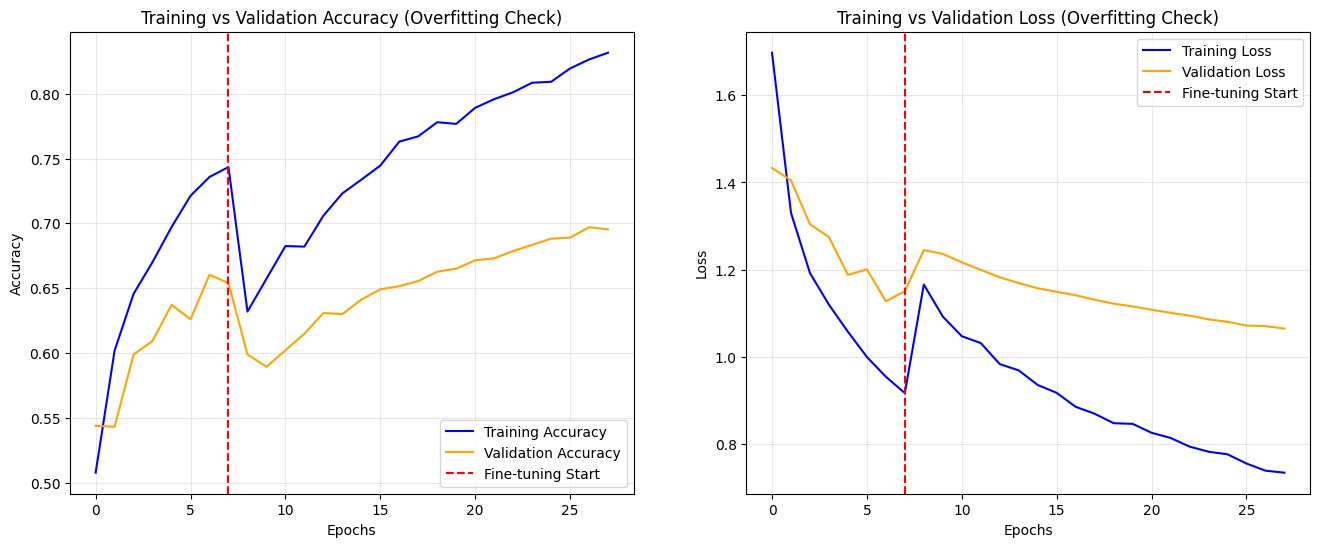


⚙️ Generating Detailed Reports...

📊 DETAILED CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

 Combination       0.92      0.75      0.82        75
         Dry       0.70      0.79      0.74       193
      Normal       0.78      0.73      0.75       264
        Oily       0.71      0.73      0.72       191

    accuracy                           0.75       723
   macro avg       0.78      0.75      0.76       723
weighted avg       0.75      0.75      0.75       723

------------------------------------------------------------


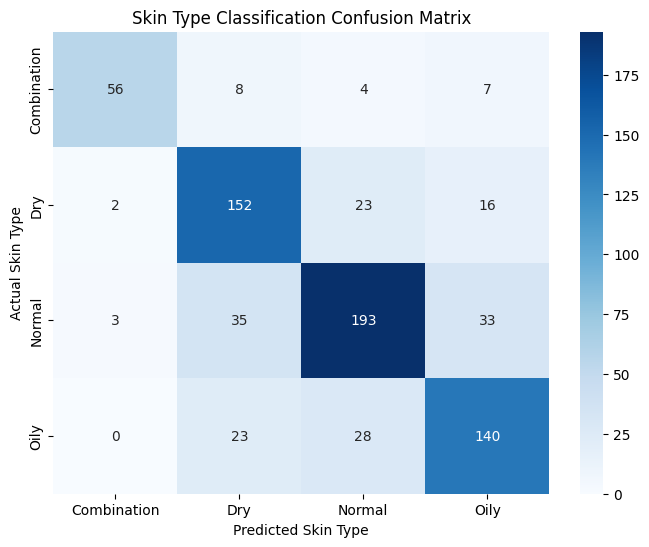

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =====================================================================
# 1. FINAL TEST ACCURACY
# =====================================================================
print("\n--- FINAL EVALUATION RESULTS ---")
test_loss, test_acc = skin_type_model.evaluate(type_test_gen, verbose=0)
print(f"🏆 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss: {test_loss:.4f}")

# =====================================================================
# 2. STITCH HISTORY DATA (Overfitting Check Graphs)
# =====================================================================
acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
loss = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

epochs_range = range(len(acc))
stage_2_start = len(history_stage1.history['accuracy']) - 1

plt.figure(figsize=(16, 6))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=stage_2_start, color='red', linestyle='--', label='Fine-tuning Start')
plt.title('Training vs Validation Accuracy (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.axvline(x=stage_2_start, color='red', linestyle='--', label='Fine-tuning Start')
plt.title('Training vs Validation Loss (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# =====================================================================
# 3. CLASSIFICATION REPORT & CONFUSION MATRIX
# =====================================================================
print("\n⚙️ Generating Detailed Reports...")
type_test_gen.reset()
y_pred_probs = skin_type_model.predict(type_test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = type_test_gen.classes
class_names = list(type_test_gen.class_indices.keys())

print("\n📊 DETAILED CLASSIFICATION REPORT:")
print("-" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("-" * 60)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Skin Type')
plt.xlabel('Predicted Skin Type')
plt.title('Skin Type Classification Confusion Matrix')
plt.show()

### Step 3: Test the Model on Individual Images
Use this cell to upload a photo (e.g., from your phone or computer) to see what skin type the model detects.

Saving Oily-face.jpg to Oily-face.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


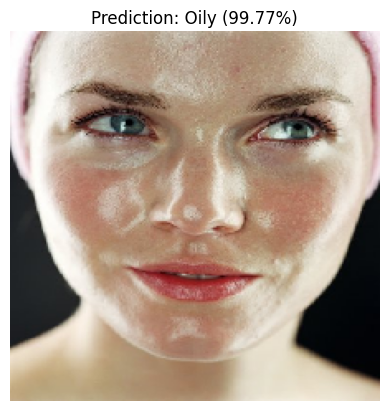


Full Analysis:
Combination: 0.00%
Dry: 0.09%
Normal: 0.13%
Oily: 99.77%


In [10]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import json

# 1. Load class mapping
with open('skin_type_classes.json', 'r') as f:
    class_indices = json.load(f)
class_names = {v: k for k, v in class_indices.items()}

# 2. Upload file
uploaded = files.upload()

for fn in uploaded.keys():
    # 3. Preprocess image
    path = fn
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) # EfficientNet expects [0-255] range

    # 4. Predict
    preds = skin_type_model.predict(x)
    score = tf.nn.softmax(preds[0])

    # 5. Display Result
    plt.imshow(img)
    plt.axis('off')
    predicted_class = class_names[np.argmax(preds)]
    confidence = 100 * np.max(preds)

    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.show()

    print(f"\nFull Analysis:")
    for i, class_name in class_names.items():
        print(f"{class_name}: {preds[0][i]*100:.2f}%")